In [1]:
# =========================
# 1. Imports and Config
# =========================
import os
import json
import random
from dataclasses import dataclass, asdict
from typing import List, Dict, Any

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from google.colab import drive

# Reproducibility
random.seed(42)

IMG_SIZE = 256
BACKGROUND_COLOR = "white"

SHAPES = ["square", "circle", "triangle"]
COLORS = {
    "red": (220, 20, 60),
    "blue": (65, 105, 225),
    "green": (34, 139, 34),
    "yellow": (255, 215, 0),
}

In [2]:
# =========================
# 2. Mount Drive and Paths
# =========================
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/COMP646/final project"
DATA_PATH = os.path.join(BASE_PATH, "data")
IMG_PATH = os.path.join(DATA_PATH, "images")

os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(IMG_PATH, exist_ok=True)

print("Base folder:", BASE_PATH)
print("Data folder:", DATA_PATH)
print("Image folder:", IMG_PATH)

Mounted at /content/drive
Base folder: /content/drive/MyDrive/Colab Notebooks/COMP646/final project
Data folder: /content/drive/MyDrive/Colab Notebooks/COMP646/final project/data
Image folder: /content/drive/MyDrive/Colab Notebooks/COMP646/final project/data/images


In [3]:
# =========================
# 3. Object Definition
# =========================
@dataclass
class SceneObject:
    obj_id: int
    shape: str
    color: str
    x: int
    y: int
    size: int

    def to_dict(self) -> Dict[str, Any]:
        return asdict(self)

In [4]:
# =========================
# 4. Drawing Utilities
# =========================
def draw_square(draw: ImageDraw.ImageDraw, x: int, y: int, size: int, color_rgb):
    half = size // 2
    draw.rectangle([x - half, y - half, x + half, y + half], fill=color_rgb, outline="black")

def draw_circle(draw: ImageDraw.ImageDraw, x: int, y: int, size: int, color_rgb):
    half = size // 2
    draw.ellipse([x - half, y - half, x + half, y + half], fill=color_rgb, outline="black")

def draw_triangle(draw: ImageDraw.ImageDraw, x: int, y: int, size: int, color_rgb):
    half = size // 2
    points = [
        (x, y - half),
        (x - half, y + half),
        (x + half, y + half),
    ]
    draw.polygon(points, fill=color_rgb, outline="black")

def draw_object(draw: ImageDraw.ImageDraw, obj: SceneObject):
    color_rgb = COLORS[obj.color]
    if obj.shape == "square":
        draw_square(draw, obj.x, obj.y, obj.size, color_rgb)
    elif obj.shape == "circle":
        draw_circle(draw, obj.x, obj.y, obj.size, color_rgb)
    elif obj.shape == "triangle":
        draw_triangle(draw, obj.x, obj.y, obj.size, color_rgb)
    else:
        raise ValueError(f"Unknown shape: {obj.shape}")

In [5]:
# =========================
# 5. Scene Generation
# =========================
def sample_position(size: int, margin: int = 20):
    half = size // 2
    x = random.randint(margin + half, IMG_SIZE - margin - half)
    y = random.randint(margin + half, IMG_SIZE - margin - half)
    return x, y

def generate_random_object(obj_id: int) -> SceneObject:
    shape = random.choice(SHAPES)
    color = random.choice(list(COLORS.keys()))
    size = random.randint(28, 42)
    x, y = sample_position(size)
    return SceneObject(obj_id=obj_id, shape=shape, color=color, x=x, y=y, size=size)

def generate_scene(num_objects: int = None):
    if num_objects is None:
        num_objects = random.randint(3, 6)

    objects: List[SceneObject] = [generate_random_object(i) for i in range(num_objects)]

    image = Image.new("RGB", (IMG_SIZE, IMG_SIZE), BACKGROUND_COLOR)
    draw = ImageDraw.Draw(image)

    for obj in objects:
        draw_object(draw, obj)

    return image, objects

In [6]:
# =========================
# 6. Query Helper Functions
# =========================
def count_matching_objects(objects: List[SceneObject], target_color: str, target_shape: str) -> int:
    return sum(1 for obj in objects if obj.color == target_color and obj.shape == target_shape)

def exists_matching_object(objects: List[SceneObject], target_color: str, target_shape: str) -> bool:
    return any(obj.color == target_color and obj.shape == target_shape for obj in objects)

def is_left_of(obj1: SceneObject, obj2: SceneObject) -> bool:
    return obj1.x < obj2.x

def is_above(obj1: SceneObject, obj2: SceneObject) -> bool:
    return obj1.y < obj2.y

def get_existing_combinations(objects: List[SceneObject]):
    return list(set((obj.color, obj.shape) for obj in objects))

def get_non_existing_combinations(objects: List[SceneObject]):
    all_combinations = [(c, s) for c in COLORS.keys() for s in SHAPES]
    existing_combinations = get_existing_combinations(objects)
    return [comb for comb in all_combinations if comb not in existing_combinations]

def get_unique_objects(objects: List[SceneObject]):
    combo_counts = {}
    for obj in objects:
        key = (obj.color, obj.shape)
        combo_counts[key] = combo_counts.get(key, 0) + 1

    unique_objs = [
        obj for obj in objects
        if combo_counts[(obj.color, obj.shape)] == 1
    ]
    return unique_objs

In [7]:
# =========================
# 7. Query Generation
# =========================
def generate_query(objects: List[SceneObject], forced_query_type: str = None):
    if forced_query_type is not None:
        query_type = forced_query_type
    else:
        query_type = random.choice(["count", "existence", "spatial", "comparison"])

    # -------------------------
    # 1. COUNT QUERY
    # -------------------------
    if query_type == "count":
        existing_combinations = get_existing_combinations(objects)
        non_existing_combinations = get_non_existing_combinations(objects)

        if random.random() < 0.5 and existing_combinations:
            target_color, target_shape = random.choice(existing_combinations)
            exists = True
        else:
            if non_existing_combinations:
                target_color, target_shape = random.choice(non_existing_combinations)
                exists = False
            else:
                target_color, target_shape = random.choice(existing_combinations)
                exists = True

        query = f"How many {target_color} {target_shape}s are present?"
        answer = count_matching_objects(objects, target_color, target_shape)

        metadata = {
            "query_type": "count",
            "target_color": target_color,
            "target_shape": target_shape,
            "exists_in_scene": exists
        }
        return query, answer, metadata

    # -------------------------
    # 2. EXISTENCE QUERY
    # -------------------------
    if query_type == "existence":
        existing_combinations = get_existing_combinations(objects)
        non_existing_combinations = get_non_existing_combinations(objects)

        if random.random() < 0.5 and existing_combinations:
            target_color, target_shape = random.choice(existing_combinations)
            exists = True
        else:
            if non_existing_combinations:
                target_color, target_shape = random.choice(non_existing_combinations)
                exists = False
            else:
                target_color, target_shape = random.choice(existing_combinations)
                exists = True

        query = f"Is there a {target_color} {target_shape}?"
        answer = "yes" if exists else "no"

        metadata = {
            "query_type": "existence",
            "target_color": target_color,
            "target_shape": target_shape,
            "exists_in_scene": exists
        }
        return query, answer, metadata

    # -------------------------
    # 3. SPATIAL QUERY
    # -------------------------
    if query_type == "spatial":
        unique_objects = get_unique_objects(objects)

        # if not enough unique objects, fallback to existence
        if len(unique_objects) < 2:
            return generate_query(objects, forced_query_type="existence")

        obj1, obj2 = random.sample(unique_objects, 2)
        relation = random.choice(["left", "above"])

        if random.random() < 0.5:
            first_obj, second_obj = obj1, obj2
        else:
            first_obj, second_obj = obj2, obj1

        if relation == "left":
            query = f"Is the {first_obj.color} {first_obj.shape} left of the {second_obj.color} {second_obj.shape}?"
            answer = "yes" if is_left_of(first_obj, second_obj) else "no"
        else:
            query = f"Is the {first_obj.color} {first_obj.shape} above the {second_obj.color} {second_obj.shape}?"
            answer = "yes" if is_above(first_obj, second_obj) else "no"

        metadata = {
            "query_type": "spatial",
            "relation": relation,
            "object_1": {"color": first_obj.color, "shape": first_obj.shape, "id": first_obj.obj_id},
            "object_2": {"color": second_obj.color, "shape": second_obj.shape, "id": second_obj.obj_id}
        }
        return query, answer, metadata

    # -------------------------
    # 4. COMPARISON QUERY
    # -------------------------
    if query_type == "comparison":
        all_combinations = [(c, s) for c in COLORS.keys() for s in SHAPES]

        max_tries = 30
        chosen = False

        for _ in range(max_tries):
            color1, shape1 = random.choice(all_combinations)
            color2, shape2 = random.choice(all_combinations)

            if (color1, shape1) == (color2, shape2):
                continue

            count1 = count_matching_objects(objects, color1, shape1)
            count2 = count_matching_objects(objects, color2, shape2)

            # prefer informative comparisons
            if count1 != count2:
                chosen = True
                break

        # fallback if couldn't find unequal counts
        if not chosen:
            valid_pairs = [
                (a, b) for a in all_combinations for b in all_combinations
                if a != b
            ]
            (color1, shape1), (color2, shape2) = random.choice(valid_pairs)
            count1 = count_matching_objects(objects, color1, shape1)
            count2 = count_matching_objects(objects, color2, shape2)

        query = f"Are there more {color1} {shape1}s than {color2} {shape2}s?"
        answer = "yes" if count1 > count2 else "no"

        metadata = {
            "query_type": "comparison",
            "target_1": {"color": color1, "shape": shape1, "count": count1},
            "target_2": {"color": color2, "shape": shape2, "count": count2}
        }
        return query, answer, metadata

In [8]:
# =========================
# 8. Visualization Utility
# =========================
def show_sample(image: Image.Image, objects: List[Any], query: str, answer: Any, metadata: Dict[str, Any]):
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Synthetic Scene")
    plt.show()

    print("Objects:")
    for obj in objects:
        if isinstance(obj, SceneObject):
            print(obj.to_dict())
        else:
            print(obj)

    print("\nQuery:", query)
    print("Answer:", answer)
    print("Metadata:", metadata)

In [9]:
# =========================
# 9. Unified Sample Record
# =========================
def generate_sample(num_objects: int = None, forced_query_type: str = None):
    image, objects = generate_scene(num_objects=num_objects)
    query, answer, metadata = generate_query(objects, forced_query_type=forced_query_type)

    sample = {
        "image": image,
        "objects": [obj.to_dict() for obj in objects],
        "query": query,
        "answer": answer,
        "metadata": metadata,
    }
    return sample

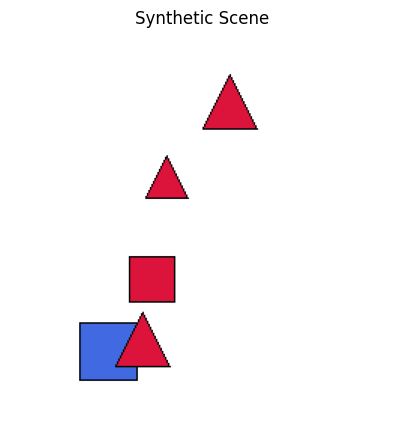

Objects:
{'obj_id': 0, 'shape': 'triangle', 'color': 'red', 'x': 104, 'y': 96, 'size': 28}
{'obj_id': 1, 'shape': 'square', 'color': 'blue', 'x': 65, 'y': 212, 'size': 39}
{'obj_id': 2, 'shape': 'triangle', 'color': 'red', 'x': 146, 'y': 46, 'size': 37}
{'obj_id': 3, 'shape': 'square', 'color': 'red', 'x': 94, 'y': 164, 'size': 31}
{'obj_id': 4, 'shape': 'triangle', 'color': 'red', 'x': 88, 'y': 204, 'size': 36}

Query: Are there more blue squares than green circles?
Answer: yes
Metadata: {'query_type': 'comparison', 'target_1': {'color': 'blue', 'shape': 'square', 'count': 1}, 'target_2': {'color': 'green', 'shape': 'circle', 'count': 0}}


In [10]:
# =========================
# 10. Single Sample Demo
# =========================
sample = generate_sample(num_objects=5)

show_sample(
    sample["image"],
    sample["objects"],
    sample["query"],
    sample["answer"],
    sample["metadata"]
)

In [11]:
# =========================
# 11. Generate Dataset
# =========================
def generate_dataset(n: int = 10, num_objects: int = None):
    dataset = []
    query_types = ["count", "existence", "spatial", "comparison"]

    for i in range(n):
        forced_qtype = query_types[i % len(query_types)]
        dataset.append(generate_sample(num_objects=num_objects, forced_query_type=forced_qtype))

    random.shuffle(dataset)
    return dataset

dataset = generate_dataset(12)

for i, sample in enumerate(dataset[:6]):
    print(f"--- Sample {i+1} ---")
    print("Query:", sample["query"])
    print("Answer:", sample["answer"])
    print("Metadata:", sample["metadata"])
    print()

--- Sample 1 ---
Query: Is the red square left of the red circle?
Answer: yes
Metadata: {'query_type': 'spatial', 'relation': 'left', 'object_1': {'color': 'red', 'shape': 'square', 'id': 4}, 'object_2': {'color': 'red', 'shape': 'circle', 'id': 5}}

--- Sample 2 ---
Query: Is there a green triangle?
Answer: yes
Metadata: {'query_type': 'existence', 'target_color': 'green', 'target_shape': 'triangle', 'exists_in_scene': True}

--- Sample 3 ---
Query: Are there more green circles than green triangles?
Answer: no
Metadata: {'query_type': 'comparison', 'target_1': {'color': 'green', 'shape': 'circle', 'count': 0}, 'target_2': {'color': 'green', 'shape': 'triangle', 'count': 1}}

--- Sample 4 ---
Query: Are there more blue squares than red circles?
Answer: no
Metadata: {'query_type': 'comparison', 'target_1': {'color': 'blue', 'shape': 'square', 'count': 0}, 'target_2': {'color': 'red', 'shape': 'circle', 'count': 1}}

--- Sample 5 ---
Query: Is the red square above the yellow square?
Answ

In [12]:
# =========================
# 12. Dataset Sanity Check
# =========================
dataset = generate_dataset(200)

query_type_counts = {}
for s in dataset:
    qtype = s["metadata"]["query_type"]
    query_type_counts[qtype] = query_type_counts.get(qtype, 0) + 1

print("Total samples:", len(dataset))
print("Query type distribution:")
for k, v in query_type_counts.items():
    print(f"  {k}: {v}")

Total samples: 200
Query type distribution:
  spatial: 44
  count: 50
  existence: 56
  comparison: 50


In [13]:
# =========================
# 13. Save Dataset
# =========================
def save_dataset(dataset: List[Dict[str, Any]], dataset_name: str):
    json_records = []

    for i, sample in enumerate(dataset):
        img_filename = f"{dataset_name}_{i:05d}.png"
        img_path = os.path.join(IMG_PATH, img_filename)

        # save image
        sample["image"].save(img_path)

        # save record without PIL image object
        json_records.append({
            "image_filename": img_filename,
            "objects": sample["objects"],
            "query": sample["query"],
            "answer": sample["answer"],
            "metadata": sample["metadata"]
        })

    json_path = os.path.join(DATA_PATH, f"{dataset_name}.json")
    with open(json_path, "w") as f:
        json.dump(json_records, f, indent=2)

    print(f"Saved {len(dataset)} samples to:")
    print(json_path)
    return json_path

In [14]:
# =========================
# 14. Create and Save Final Train/Test Datasets
# =========================
# T4-friendly scale: large enough for a more stable custom model, but still
# manageable for BLIP inference and Colab runtime.
train_dataset = generate_dataset(n=3000, num_objects=None)
test_dataset = generate_dataset(n=600, num_objects=None)

train_json_path = save_dataset(train_dataset, dataset_name="synthetic_vlm_train")
test_json_path = save_dataset(test_dataset, dataset_name="synthetic_vlm_test")

print("Saved train samples:", len(train_dataset))
print("Saved test samples:", len(test_dataset))


Saved 3000 samples to:
/content/drive/MyDrive/Colab Notebooks/COMP646/final project/data/synthetic_vlm_train.json
Saved 600 samples to:
/content/drive/MyDrive/Colab Notebooks/COMP646/final project/data/synthetic_vlm_test.json
Saved train samples: 3000
Saved test samples: 600


In [15]:
# =========================
# 15. Load Dataset Back
# =========================
def load_dataset(dataset_name: str):
    json_path = os.path.join(DATA_PATH, f"{dataset_name}.json")

    with open(json_path, "r") as f:
        loaded = json.load(f)

    print(f"Loaded {len(loaded)} samples from:")
    print(json_path)
    return loaded

loaded_train = load_dataset("synthetic_vlm_train")
loaded_test = load_dataset("synthetic_vlm_test")

print("Train example query:", loaded_train[0]["query"])
print("Test example query:", loaded_test[0]["query"])

Loaded 3000 samples from:
/content/drive/MyDrive/Colab Notebooks/COMP646/final project/data/synthetic_vlm_train.json
Loaded 600 samples from:
/content/drive/MyDrive/Colab Notebooks/COMP646/final project/data/synthetic_vlm_test.json
Train example query: Is the yellow circle left of the green square?
Test example query: Are there more yellow triangles than green squares?


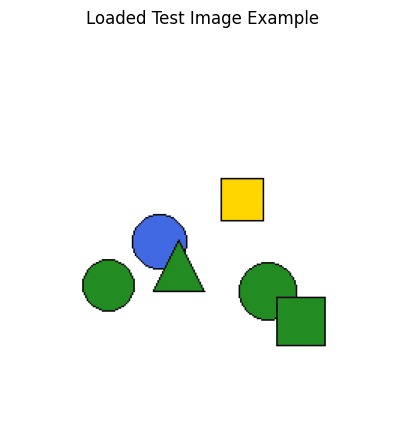

Query: Are there more yellow triangles than green squares?
Answer: no
Metadata: {'query_type': 'comparison', 'target_1': {'color': 'yellow', 'shape': 'triangle', 'count': 0}, 'target_2': {'color': 'green', 'shape': 'square', 'count': 1}}


In [16]:
# =========================
# 16. Load One Image Example from Disk
# =========================
def load_image_from_record(record):
    img_path = os.path.join(IMG_PATH, record["image_filename"])
    image = Image.open(img_path).convert("RGB")
    return image

example_record = loaded_test[0]
example_image = load_image_from_record(example_record)

plt.figure(figsize=(5, 5))
plt.imshow(example_image)
plt.axis("off")
plt.title("Loaded Test Image Example")
plt.show()

print("Query:", example_record["query"])
print("Answer:", example_record["answer"])
print("Metadata:", example_record["metadata"])